In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("netflix_vs_sleep_cleaned.csv")

In [3]:
# --- 1️⃣ Basic Overview ---
print(df.head())
print(df.info())
print(df.describe())

                                user_id  watch_date day_of_week start_time  \
0  028d89e2-62bb-4f89-8707-6ade4000423f  2025-05-29      Monday      19:59   
1  1b3f1486-3715-42e3-af46-838da4a8dab2  2025-02-21      Monday      22:41   
2  6a7514c9-44dc-4a81-b0f0-a866ac346602  2025-03-18      Monday      19:27   
3  502ad54a-083d-4c98-a875-7596708d53b6  2025-02-23   Wednesday      20:19   
4  7c7970b3-360f-4717-a81c-54f5f53b1d11  2025-03-11      Friday      04:51   

  end_time device_type content_type  episodes_watched  sleep_hours  binge_flag  
0    23:59          TV       Series                 3          4.2           0  
1    23:41     Unknown        Movie                 5          4.2           1  
2    23:27      Tablet        Movie                 3          6.8           0  
3    23:19      Laptop       Series                 5          6.4           1  
4    05:51     Unknown        Movie                 5          4.3           1  
<class 'pandas.core.frame.DataFrame'>
RangeIn

In [4]:
# --- 2️⃣ Viewing Patterns by Time of Day ---
# Extract hour from start_time
df['start_hour'] = pd.to_datetime(df['start_time'], format="%H:%M").dt.hour
viewing_by_hour = df.groupby('start_hour').size().reset_index(name='view_count')
print(viewing_by_hour)


    start_hour  view_count
0            0         159
1            1         170
2            2         177
3            3         154
4            4         161
5            5         178
6           18         631
7           19         683
8           20         675
9           21         659
10          22         669
11          23         684


In [5]:
# --- 3️⃣ Binge vs Non-Binge: Sleep Hours ---
binge_sleep = df.groupby('binge_flag')['sleep_hours'].mean().reset_index()
binge_sleep['binge_flag'] = binge_sleep['binge_flag'].map({0: 'Non-Binge', 1: 'Binge'})
print(binge_sleep)


  binge_flag  sleep_hours
0  Non-Binge     5.965047
1      Binge     5.875820


In [6]:
# --- 4️⃣ Device Usage Share ---
device_share = df['device_type'].value_counts(normalize=True).reset_index()
device_share.columns = ['device_type', 'percentage']
print(device_share)

  device_type  percentage
0      Mobile      0.2914
1      Laptop      0.2784
2          TV      0.1468
3     Unknown      0.1426
4      Tablet      0.1408


In [7]:
# --- 5️⃣ Episodes Watched by Day of Week ---
episodes_by_day = df.groupby('day_of_week')['episodes_watched'].mean().reset_index()
print(episodes_by_day)


  day_of_week  episodes_watched
0      Friday          3.586142
1      Monday          3.674257
2    Saturday          3.567568
3      Sunday          3.610568
4    Thursday          3.645161
5     Tuesday          3.648785
6   Wednesday          3.600000


In [8]:
# --- 6️⃣ Sleep Deficit Over Week ---
sleep_by_day = df.groupby('day_of_week')['sleep_hours'].mean().reset_index()
print(sleep_by_day)

  day_of_week  sleep_hours
0      Friday     5.883521
1      Monday     5.949901
2    Saturday     5.889605
3      Sunday     5.959295
4    Thursday     5.989516
5     Tuesday     5.879150
6   Wednesday     5.908878


C:\Users\Samhitha Kasyap\AppData\Local\Temp\ipykernel_28872\625957130.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=viewing_by_hour, x='start_hour', y='view_count', palette='viridis')


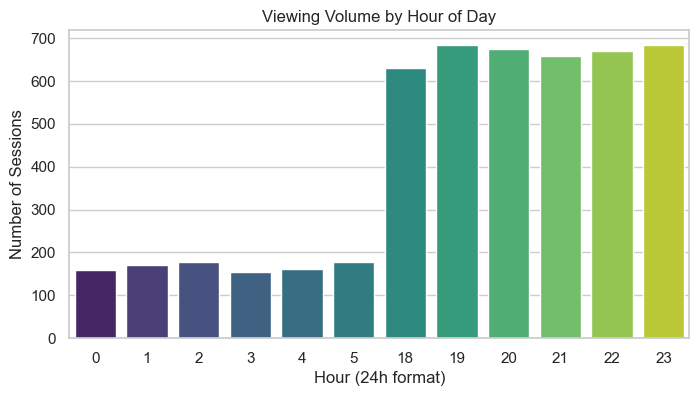

In [9]:
# --- 7️⃣ Visualization Examples ---
sns.set(style="whitegrid")

# 1. Viewing Volume by Hour
plt.figure(figsize=(8,4))
sns.barplot(data=viewing_by_hour, x='start_hour', y='view_count', palette='viridis')
plt.title("Viewing Volume by Hour of Day")
plt.xlabel("Hour (24h format)")
plt.ylabel("Number of Sessions")
plt.show()

C:\Users\Samhitha Kasyap\AppData\Local\Temp\ipykernel_28872\3558733819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=binge_sleep, x='binge_flag', y='sleep_hours', palette='coolwarm')


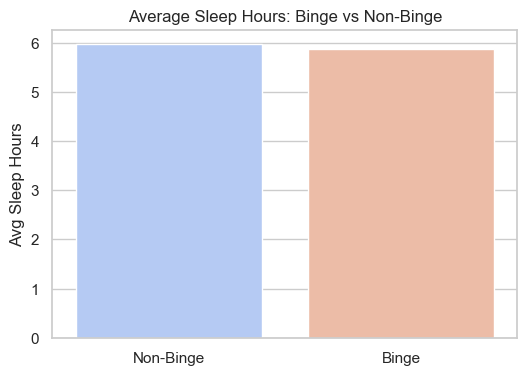

In [10]:
# 2. Sleep Hours: Binge vs Non-Binge
plt.figure(figsize=(6,4))
sns.barplot(data=binge_sleep, x='binge_flag', y='sleep_hours', palette='coolwarm')
plt.title("Average Sleep Hours: Binge vs Non-Binge")
plt.xlabel("")
plt.ylabel("Avg Sleep Hours")
plt.show()

C:\Users\Samhitha Kasyap\AppData\Local\Temp\ipykernel_28872\839549027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_share, x='device_type', y='percentage', palette='muted')


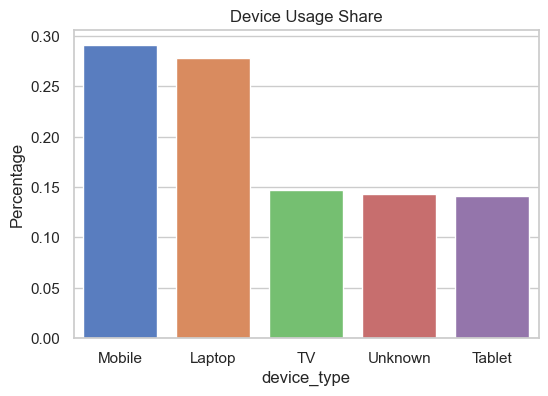

In [11]:
# 3. Device Usage Share
plt.figure(figsize=(6,4))
sns.barplot(data=device_share, x='device_type', y='percentage', palette='muted')
plt.title("Device Usage Share")
plt.ylabel("Percentage")
plt.show()


In [12]:
import pandas as pd
from datetime import datetime, timedelta

df = pd.read_csv("netflix_vs_sleep_cleaned.csv")

# Parse times safely (24h strings like "23:15")
def parse_hhmm(s):
    return datetime.strptime(s, "%H:%M").time()

df['start_t'] = df['start_time'].apply(parse_hhmm)
df['end_t']   = df['end_time'].apply(parse_hhmm)

# Build datetimes on same dummy date; add 1 day if end < start (past midnight sessions)
base = datetime(2000,1,1)
df['start_dt'] = df['start_t'].apply(lambda t: datetime.combine(base.date(), t))
df['end_dt']   = df['end_t'].apply(lambda t: datetime.combine(base.date(), t))
df.loc[df['end_dt'] < df['start_dt'], 'end_dt'] += timedelta(days=1)

df['session_minutes'] = (df['end_dt'] - df['start_dt']).dt.total_seconds() / 60

# Late-night flag = starts 22:00–02:59
df['start_hour'] = df['start_dt'].dt.hour
df['late_night'] = df['start_hour'].between(22, 23) | df['start_hour'].between(0, 2)

# Quick sanity
df[['start_time','end_time','session_minutes','late_night']].head()


,start_time,end_time,session_minutes,late_night
0,19:59,23:59,240.0,False
1,22:41,23:41,60.0,True
2,19:27,23:27,240.0,False
3,20:19,23:19,180.0,False
4,04:51,05:51,60.0,False
